# HEADER 1

## Imports

In [2]:
# Core
import os
import json
import pandas as pd
import numpy as np

# Stratified Sampling and Hyperparameter Tuning
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import GridSearchCV

# Metrics
from sklearn.metrics import roc_auc_score

# Machine Learning Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Feature scaler
from sklearn.preprocessing import StandardScaler

# Modules from src directory
from preprocessing_mask_segmentation import preprocessing as pre
from shape_features import shape_features as sf
from pyrandomics_playground import pyrandomics_implementation as pr
from split import split
from feature_engineering import selection as sel
from evaluation import model_eval
from resize_image import resize as res

# Visualisation
# import matplotlib.pyplot as plt
# import seaborn as sns

## Constant Variables

In [3]:
IMAGES_PATH = "../images/"
CONFIG_JSON_PATH = "config.json"

CSV_PATH = "../labels.csv"
MERGED_CSV_AND_FEATURE_PATH = "../output/features.csv"
ASSESSMENT_ONLY_PATH = "../output/assessment_only_vector.csv"

PLOT_PATH = "../output/performance_comparison.png"

X_TRAIN_PATH = "../output/X_train.csv"
X_TEST_PATH = "../output/X_test.csv"
Y_TRAIN_PATH = "../output/y_train.csv"
Y_TEST_PATH = "../output/y_test.csv"

X_TRAIN_HYBRID = "../output/X_train_hybrid.csv"
X_TEST_HYBRID = "../output/X_test_hybrid.csv"
Y_TRAIN_HYBRID = "../output/y_train_hybrid.csv"
Y_TEST_HYBRID = "../output/y_test_hybrid.csv"

X_TRAIN_ASSESSMENT_ONLY_PATH = "../output/x_train_assessment_only.csv"
X_TEST_ASSESSMENT_ONLY_PATH = "../output/x_test_assessment_only.csv"
Y_TRAIN_ASSESSMENT_ONLY_PATH = "../output/y_train_assessment_only.csv"
Y_TEST_ASSESSMENT_ONLY_PATH = "../output/y_test_assessment_only.csv"

In [4]:
# Import configuration file
with open(CONFIG_JSON_PATH) as f:
    config = json.load(f)

## Import, Preprocessing and Feature Extraction

In [5]:
if not config['import_features_instead_of_training']:
    images_names = sorted([f for f in os.listdir(IMAGES_PATH) if f.endswith('.png')])

    # Import and preprocess images
    images_dict = {}
    for image_name in images_names:
        full_path = os.path.join(IMAGES_PATH, image_name)
        key = image_name.split('.')[0]
        img = pre.clean_mask(full_path)

        if config['resize_images']:
            # Image Resizing - only if CNN is used
            img = res.resize_with_padding(img)
            img = np.array(img)
        images_dict[key] = img

    # Extract features from images
    features_results = []

    for name, img in images_dict.items():
        full_path = os.path.join(IMAGES_PATH, name + ".png")
        features = sf.extract_shape_features(img)  # Extract features using region props based module
        pr_features = pr.extract_shape_features_from_mask(full_path)  # Extract features using pyradiomics based module
        features.update(pr_features)  # Update features dictionary with pyradiomics features
        if features:
            features['id'] = name
            features_results.append(features)
        else:
            print(f"{name} omitted (empty mask or unexpected error).")

    # Convert features_results into Pandas DataFrame
    df_feature_results = pd.DataFrame(features_results)

    # Import CSV file and
    csv_file = pd.read_csv(CSV_PATH)

    # Convert id columns to string to prepare merge
    csv_file['id'] = csv_file['id'].astype(str)
    df_feature_results["id"] = df_feature_results["id"].astype(str)

    # Merge CSV columns and feature DataFrame into one final DataFrame
    df_features = pd.merge(csv_file, df_feature_results, left_on='id', right_on='id')

    # Drop useless columns and convert target feature into binary value
    df_features.drop(columns='abnormality_type', inplace=True)
    mapping = {'MALIGNANT': 1, 'BENIGN': 0}
    df_features['pathology'] = df_features['pathology'].map(mapping)
else:
    df_features = pd.read_csv(MERGED_CSV_AND_FEATURE_PATH)

In [6]:
# Drop rows with BI-RADS assessment not included in config.json file
df_features = df_features[df_features['assessment'].isin(config['selected_assessments'])]

assessment_remaining_cols = ['id', 'patient_id', 'pathology', 'assessment']
df_assessment_only = df_features[assessment_remaining_cols]

# Export final DataFrame into CSV file
df_features.to_csv(MERGED_CSV_AND_FEATURE_PATH, index=False)
df_assessment_only.to_csv(ASSESSMENT_ONLY_PATH, index=False)

## Test of Feature Extraction and Preprocessing

In [7]:
df_features

,id,patient_id,assessment,pathology,Area,Area Bounding Box,Area Convex,Area Filled,Axis Major Length,Axis Minor Length,...,Hu Moment 7,original_shape2D_Elongation,original_shape2D_MajorAxisLength,original_shape2D_MaximumDiameter,original_shape2D_MeshSurface,original_shape2D_MinorAxisLength,original_shape2D_Perimeter,original_shape2D_PerimeterSurfaceRatio,original_shape2D_PixelSurface,original_shape2D_Sphericity
0,1001,P_00001,4,1,120176.0,184775.0,144592.0,120176.0,437.817532,369.842129,...,41.605810,0.840962,447.005783,502.236996,124054.0,375.915034,11341.453814,0.091424,124881.0,0.110088
1,1002,P_00001,4,1,32114.0,54432.0,39160.0,32114.0,215.156997,204.049262,...,35.156400,0.943530,221.291459,262.937255,33513.0,208.795081,4451.100356,0.132817,33875.0,0.145796
2,1003,P_00004,4,0,113057.0,162306.0,132259.0,113057.0,403.087349,373.343420,...,-39.577490,0.925515,409.909988,452.659916,116337.0,379.377683,10081.557277,0.086658,117128.0,0.119932
3,1004,P_00004,4,0,89182.0,147452.0,111392.0,89182.0,361.346738,333.637192,...,-39.404040,0.923041,369.899218,429.382114,92938.0,341.432140,11268.303669,0.121245,93806.0,0.095905
4,1005,P_00004,4,0,91546.0,151434.0,108858.0,91546.0,389.640992,311.266317,...,38.290290,0.801773,396.665021,441.897047,94536.0,318.035325,9069.472791,0.095937,95248.0,0.120177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1659,2660,P_01825,3,0,27042.0,44522.0,33279.0,27042.0,225.676587,163.949792,...,-34.753800,0.738651,231.590498,264.151472,28669.0,171.064565,4935.097398,0.172141,29063.0,0.121623
1660,2661,P_01833,5,1,168417.0,231632.0,179350.0,168417.0,495.387348,442.668797,...,-41.506033,0.894221,500.356603,532.379564,171250.0,447.429134,8814.252445,0.051470,171959.0,0.166431
1661,2662,P_01865,4,1,28723.0,50935.0,40694.0,28723.0,317.452191,141.700567,...,36.442295,0.452301,323.419774,330.492057,30312.0,146.283225,4707.627268,0.155306,30656.0,0.131102
1662,2663,P_01912,5,1,96990.0,149408.0,112074.0,96990.0,387.619283,329.299319,...,-38.783403,0.849831,394.723599,434.885042,99995.0,335.448353,8754.813844,0.087553,100659.0,0.128040


In [8]:
df_features.describe()

,id,assessment,pathology,Area,Area Bounding Box,Area Convex,Area Filled,Axis Major Length,Axis Minor Length,Centroid X,...,Hu Moment 7,original_shape2D_Elongation,original_shape2D_MajorAxisLength,original_shape2D_MaximumDiameter,original_shape2D_MeshSurface,original_shape2D_MinorAxisLength,original_shape2D_Perimeter,original_shape2D_PerimeterSurfaceRatio,original_shape2D_PixelSurface,original_shape2D_Sphericity
count,1664.00000,1664.000000,1664.000000,1.664000e+03,1.664000e+03,1.664000e+03,1.664000e+03,1664.000000,1664.000000,1664.000000,...,1664.000000,1664.000000,1664.000000,1664.000000,1.664000e+03,1664.000000,1664.000000,1664.000000,1.664000e+03,1664.000000
mean,1832.50000,3.501202,0.458534,7.868357e+04,1.221009e+05,9.073593e+04,7.868357e+04,334.169193,269.915583,206.031864,...,0.093411,0.815981,339.966279,373.587871,8.088757e+04,275.892554,6771.636978,0.109066,8.141759e+04,0.144375
std,480.49974,1.404828,0.498427,8.055054e+04,1.206283e+05,9.094821e+04,8.055054e+04,137.835099,113.287892,83.124890,...,37.016106,0.105319,137.912696,146.274700,8.145605e+04,113.350225,3408.396570,0.040458,8.167956e+04,0.030806
min,1001.00000,0.000000,0.000000,3.966000e+03,6.095000e+03,4.643000e+03,3.966000e+03,80.596272,52.545921,51.516357,...,-47.280762,0.235148,85.949642,99.764723,4.462000e+03,56.021813,1176.302741,0.012086,4.588000e+03,0.078946
25%,1416.75000,3.000000,0.000000,3.621375e+04,5.792400e+04,4.223800e+04,3.621375e+04,245.383208,195.395222,152.343274,...,-36.714913,0.759485,251.109973,279.028672,3.776600e+04,201.410715,4662.178567,0.082740,3.813025e+04,0.126931
50%,1832.50000,4.000000,0.000000,5.651000e+04,8.885800e+04,6.547500e+04,5.651000e+04,305.682136,247.529924,188.373131,...,26.018202,0.832634,311.029433,342.118299,5.848175e+04,253.375901,6003.902664,0.103361,5.902050e+04,0.140712
75%,2248.25000,4.000000,1.000000,9.042775e+04,1.425425e+05,1.045720e+05,9.042775e+04,383.560436,318.783599,237.281471,...,36.752786,0.892520,389.353409,428.077388,9.278538e+04,325.452030,7872.580692,0.130612,9.339600e+04,0.155642
max,2664.00000,5.000000,1.000000,1.251936e+06,1.797881e+06,1.345671e+06,1.251936e+06,1317.697863,1222.367729,811.905826,...,49.230771,0.991157,1325.946937,1380.488682,1.266556e+06,1230.996844,35311.304151,0.342320,1.269045e+06,0.469933


In [9]:
df_assessment_only

,id,patient_id,pathology,assessment
0,1001,P_00001,1,4
1,1002,P_00001,1,4
2,1003,P_00004,0,4
3,1004,P_00004,0,4
4,1005,P_00004,0,4
...,...,...,...,...
1659,2660,P_01825,0,3
1660,2661,P_01833,1,5
1661,2662,P_01865,1,4
1662,2663,P_01912,1,5


In [10]:
df_assessment_only.describe()

,id,pathology,assessment
count,1664.00000,1664.000000,1664.000000
mean,1832.50000,0.458534,3.501202
std,480.49974,0.498427,1.404828
min,1001.00000,0.000000,0.000000
25%,1416.75000,0.000000,3.000000
50%,1832.50000,0.000000,4.000000
75%,2248.25000,1.000000,4.000000
max,2664.00000,1.000000,5.000000


## Select Features

In [11]:
metadata_cols = ['id', 'patient_id', 'pathology', 'assessment']
df_dropped_cols = sel.drop_high_correlation_features(df_features, exclude=metadata_cols)

df_cleaned = df_dropped_cols[0]
dropped_features = df_dropped_cols[1]

# Drop remaining scale dependent features
remaining_scale_dependent_features = ["Area", "Orientation"]
df_cleaned = df_cleaned.drop(columns=remaining_scale_dependent_features)

Dropped 28 redundant features due to high correlation (> 0.9): ['Area Bounding Box', 'Area Convex', 'Area Filled', 'Axis Major Length', 'Axis Minor Length', 'Centroid X', 'Centroid Y', 'Equivalent Diameter', 'Feret Diameter Max', 'Perimeter', 'Aspect Ratio', 'Convexity', 'Irregularity Index', 'Roundness', 'Shape Factor', 'Relative Area', 'Hu Moment 1', 'Hu Moment 2', 'Hu Moment 3', 'original_shape2D_Elongation', 'original_shape2D_MajorAxisLength', 'original_shape2D_MaximumDiameter', 'original_shape2D_MeshSurface', 'original_shape2D_MinorAxisLength', 'original_shape2D_Perimeter', 'original_shape2D_PerimeterSurfaceRatio', 'original_shape2D_PixelSurface', 'original_shape2D_Sphericity']


## Data Split

In [12]:
drop_cols = ['id', 'patient_id', 'pathology', 'assessment']
drop_cols_without_assessment = ['id', 'patient_id', 'pathology']

# Choose 1. or 2. split function - classic or stratified_kfold-based

if config['use_classic_aware_split'] == 1:
    # 1. classic function
    X_train, X_test, y_train, y_test, is_intersect_empty = split.aware_patient_split(df_cleaned, drop_cols)

    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid, is_intersect_empty_hybrid = split.aware_patient_split(
        df_cleaned, drop_cols_without_assessment)

    X_train_assessment_only, X_test_assessment_only, y_train_assessment_only, y_test_assessment_only, is_intersect_empty_assessment_only = split.aware_patient_split(
        df_assessment_only, drop_cols_without_assessment)
else:
    # 2. stratified_kfold-based function
    X_train, X_test, y_train, y_test, is_intersect_empty = split.aware_patient_split_stratified_kfold(df_cleaned,
                                                                                                      drop_cols)

    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid, is_intersect_empty_hybrid = split.aware_patient_split_stratified_kfold(
        df_cleaned, drop_cols_without_assessment)

    X_train_assessment_only, X_test_assessment_only, y_train_assessment_only, y_test_assessment_only, is_intersect_empty_assessment_only = split.aware_patient_split_stratified_kfold(
        df_assessment_only, drop_cols_without_assessment)

# Verify that the intersection of patient IDs in Train and Test sets is empty
print(is_intersect_empty)
print(is_intersect_empty_hybrid)
print(is_intersect_empty_assessment_only)

True
True
True


## Vectors Before Features Scaling

In [13]:
X_train

,Eccentricity,Extent,Solidity,Circularity,Hu Moment 4,Hu Moment 5,Hu Moment 6,Hu Moment 7
0,0.535176,0.650391,0.831139,0.214861,-20.574172,-41.554963,-29.188242,41.605810
1,0.317155,0.589984,0.820072,0.321471,-17.634853,-35.211028,-24.604329,35.156400
2,0.377009,0.696567,0.854815,0.232702,-19.398799,-39.878430,-27.140005,-39.577490
3,0.384041,0.604821,0.800614,0.169008,-19.481583,-39.669806,-27.408701,-39.404040
4,0.601525,0.604527,0.840967,0.256437,-18.637163,37.810392,26.995989,38.290290
...,...,...,...,...,...,...,...,...
1656,0.186032,0.686282,0.907471,0.386155,-18.822849,37.470353,-25.336569,36.621682
1657,0.515203,0.615938,0.879717,0.374767,-18.034925,-36.053653,-25.250457,-37.374504
1661,0.894849,0.563915,0.705829,0.236020,-18.441229,-37.372978,-26.574930,36.442295
1662,0.527519,0.649162,0.865410,0.271296,-18.894161,-37.902603,-27.233321,-38.783403


In [14]:
X_train_hybrid

,assessment,Eccentricity,Extent,Solidity,Circularity,Hu Moment 4,Hu Moment 5,Hu Moment 6,Hu Moment 7
0,4,0.535176,0.650391,0.831139,0.214861,-20.574172,-41.554963,-29.188242,41.605810
1,4,0.317155,0.589984,0.820072,0.321471,-17.634853,-35.211028,-24.604329,35.156400
2,4,0.377009,0.696567,0.854815,0.232702,-19.398799,-39.878430,-27.140005,-39.577490
3,4,0.384041,0.604821,0.800614,0.169008,-19.481583,-39.669806,-27.408701,-39.404040
4,4,0.601525,0.604527,0.840967,0.256437,-18.637163,37.810392,26.995989,38.290290
...,...,...,...,...,...,...,...,...,...
1656,4,0.186032,0.686282,0.907471,0.386155,-18.822849,37.470353,-25.336569,36.621682
1657,4,0.515203,0.615938,0.879717,0.374767,-18.034925,-36.053653,-25.250457,-37.374504
1661,4,0.894849,0.563915,0.705829,0.236020,-18.441229,-37.372978,-26.574930,36.442295
1662,5,0.527519,0.649162,0.865410,0.271296,-18.894161,-37.902603,-27.233321,-38.783403


In [15]:
X_train_assessment_only

,assessment
0,4
1,4
2,4
3,4
4,4
...,...
1656,4
1657,4
1661,4
1662,5


## Scale Features with StandardScaler

In [16]:
# Scale standard feature vector
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Scale hybrid vector
scaler_hybrid = StandardScaler()
X_train_hybrid_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_hybrid),
    columns=X_train_hybrid.columns,
    index=X_train_hybrid.index
)
X_test_hybrid_scaled = pd.DataFrame(
    scaler.transform(X_test_hybrid),
    columns=X_test_hybrid.columns,
    index=X_test_hybrid.index
)

# Scale assessment-only vector
scaler_assessment_only = StandardScaler()
X_train_assessment_only_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_assessment_only),
    columns=X_train_assessment_only.columns,
    index=X_train_assessment_only.index
)
X_test_assessment_only_scaled = pd.DataFrame(
    scaler.transform(X_test_assessment_only),
    columns=X_test_assessment_only.columns,
    index=X_test_assessment_only.index
)

# Export X_train_scaled, X_test_scaled, y_train, y_test into CSV file
X_train_scaled.to_csv(X_TRAIN_PATH, index=False)
X_test_scaled.to_csv(X_TEST_PATH, index=False)
y_train.to_csv(Y_TRAIN_PATH, index=False)
y_test.to_csv(Y_TEST_PATH, index=False)

# Export X_train_hybrid_scaled, X_test_hybrid_scaled, y_train_hybrid, y_test_hybrid into CSV file
X_train_hybrid_scaled.to_csv(X_TRAIN_HYBRID, index=False)
X_test_hybrid_scaled.to_csv(X_TEST_HYBRID, index=False)
y_train_hybrid.to_csv(Y_TRAIN_HYBRID, index=False)
y_test_hybrid.to_csv(Y_TEST_HYBRID, index=False)

# Export X_train_assessment_only_scaled, X_test_assessment_only_scaled , y_train_assessment_only, y_test_assessment_only into CSV file
X_train_assessment_only.to_csv(X_TRAIN_ASSESSMENT_ONLY_PATH, index=False)
X_test_assessment_only.to_csv(X_TEST_ASSESSMENT_ONLY_PATH, index=False)
y_train_assessment_only.to_csv(Y_TRAIN_ASSESSMENT_ONLY_PATH, index=False)
y_test_assessment_only.to_csv(Y_TEST_ASSESSMENT_ONLY_PATH, index=False)

## Vectors After Features Scaling

In [17]:
X_train_scaled

,Eccentricity,Extent,Solidity,Circularity,Hu Moment 4,Hu Moment 5,Hu Moment 6,Hu Moment 7
0,-0.124308,0.187877,-0.621119,-1.258469,-1.475013,-0.980892,-0.984830,1.122194
1,-1.601743,-0.760369,-0.838408,-0.335424,0.320042,-0.807333,-0.806241,0.947801
2,-1.196140,0.912727,-0.156261,-1.103996,-0.757207,-0.935025,-0.905031,-1.073016
3,-1.148483,-0.527469,-1.220431,-1.655467,-0.807764,-0.929317,-0.915499,-1.068325
4,0.325305,-0.532071,-0.428150,-0.898501,-0.292073,1.190408,1.204113,1.032542
...,...,...,...,...,...,...,...,...
1656,-2.490303,0.751277,0.877563,0.224618,-0.405472,1.181105,-0.834769,0.987422
1657,-0.259660,-0.352950,0.332652,0.126015,0.075716,-0.830386,-0.831414,-1.013446
1661,2.313035,-1.169590,-3.081416,-1.075267,-0.172415,-0.866480,-0.883015,0.982572
1662,-0.176198,0.168585,0.051762,-0.769851,-0.449023,-0.880970,-0.908666,-1.051543


In [18]:
X_train_hybrid_scaled

,assessment,Eccentricity,Extent,Solidity,Circularity,Hu Moment 4,Hu Moment 5,Hu Moment 6,Hu Moment 7
0,0.359273,-0.124308,0.187877,-0.621119,-1.258469,-1.475013,-0.980892,-0.984830,1.122194
1,0.359273,-1.601743,-0.760369,-0.838408,-0.335424,0.320042,-0.807333,-0.806241,0.947801
2,0.359273,-1.196140,0.912727,-0.156261,-1.103996,-0.757207,-0.935025,-0.905031,-1.073016
3,0.359273,-1.148483,-0.527469,-1.220431,-1.655467,-0.807764,-0.929317,-0.915499,-1.068325
4,0.359273,0.325305,-0.532071,-0.428150,-0.898501,-0.292073,1.190408,1.204113,1.032542
...,...,...,...,...,...,...,...,...,...
1656,0.359273,-2.490303,0.751277,0.877563,0.224618,-0.405472,1.181105,-0.834769,0.987422
1657,0.359273,-0.259660,-0.352950,0.332652,0.126015,0.075716,-0.830386,-0.831414,-1.013446
1661,0.359273,2.313035,-1.169590,-3.081416,-1.075267,-0.172415,-0.866480,-0.883015,0.982572
1662,1.068704,-0.176198,0.168585,0.051762,-0.769851,-0.449023,-0.880970,-0.908666,-1.051543


In [19]:
X_train_assessment_only_scaled

,assessment
0,0.359273
1,0.359273
2,0.359273
3,0.359273
4,0.359273
...,...
1656,0.359273
1657,0.359273
1661,0.359273
1662,1.068704


## Model Tests

In [20]:
models_list = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5)
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

vectors = [
    {
        'config_key': 'shape_only',
        'name': 'Shape-Only',
        'X_train': X_train_scaled,
        'y_train': y_train,
        'X_test': X_test_scaled,
        'y_test': y_test
    },
    {
        'config_key': 'assessment_only',
        'name': 'BI-RADS-Score-Only',
        'X_train': X_train_assessment_only_scaled,
        'y_train': y_train_assessment_only,
        'X_test': X_test_assessment_only_scaled,
        'y_test': y_test_assessment_only
    },
    {
        'config_key': 'hybrid',
        'name': 'Hybrid (Shape + BI-RADS Score)',
        'X_train': X_train_hybrid_scaled,
        'y_train': y_train_hybrid,
        'X_test': X_test_hybrid_scaled,
        'y_test': y_test_hybrid
    }
]

# Filter out vectors list: include dictionaries with config_key in "train_and_evaluate" config.json section
vectors = [v for v in vectors if v['config_key'] in config['train_and_evaluate']]
for v in vectors:
    print(f'{v["name"]} vector selected for testing')

Shape-Only vector selected for testing
BI-RADS-Score-Only vector selected for testing
Hybrid (Shape + BI-RADS Score) vector selected for testing


## Hyperparameter Tuning

In [21]:
# Dictionary to store the best model instances for each vector
# Structure: { 'Shape-Only': {'Random Forest': best_rf_model, ...}, ... }
best_models_per_vector = {}

if config['perform_hyperparameter_tuning']:
    optimization_configs = {
        "Random Forest": {
            "model": RandomForestClassifier(random_state=42, class_weight='balanced'),
            "params": {
                'n_estimators': [100, 200, 300],
                'max_depth': [None, 10, 20],
                'min_samples_split': [2, 5],
                'min_samples_leaf': [1, 2],
            }
        },
        "SVM (RBF)": {
            "model": SVC(probability=True, random_state=42, class_weight='balanced'),
            "params": {
                'C': [0.1, 1, 10, 100],
                'gamma': ['scale', 0.1, 0.01],
                'kernel': ['rbf']
            }
        },
        "Logistic Regression": {
            "model": LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear'),
            "params": {
                'C': [0.01, 0.1, 1, 10, 100],  # Lower C - stronger regularization
                'penalty': ['l1', 'l2']
                #L1 - remove useless shape descriptors by zeroing their weights, l2 - penalize large weights but does not force them to zero
            }
        },
        "KNN": {
            "model": KNeighborsClassifier(),
            "params": {
                'n_neighbors': [3, 5, 7, 9, 11],  # Odd number of neighbours to avoid draw
                'weights': ['uniform', 'distance'],  # Distance: closer neighbour's vote is more important
                'metric': ['euclidean', 'manhattan']  # Select default metric
            }
        }
    }

    # Containers for results
    tuning_results_data = []

    # Use the same CV strategy as in the rest of the project
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Loop through Feature Vectors (Shape, BI-RADS, Hybrid)
    for vector in vectors:
        vec_name = vector['name']
        X_train_curr = vector['X_train']
        y_train_curr = vector['y_train']

        # Validation set (Just for a quick check, not used for tuning!)
        X_test_curr = vector['X_test']
        y_test_curr = vector['y_test']

        print(f"{'-' * 60}")
        print(f" TUNING FOR VECTOR: {vec_name}")
        print(f"{'-' * 60}")

        best_models_per_vector[vec_name] = {}

        # Loop through Models defined in configuration
        for model_name, opt_config in optimization_configs.items():
            print(f"Optimizing: {model_name}...")

            # GridSearchCV performs internal Cross-Validation to find best params
            grid_search = GridSearchCV(
                estimator=opt_config["model"],
                param_grid=opt_config["params"],
                cv=cv,
                scoring='roc_auc',  # Optimizing for ROC AUC
                n_jobs=-1,  # Use all available CPU cores
                verbose=1  # Show progress
            )

            # Fit GridSearch on the Training Data
            grid_search.fit(X_train_curr, y_train_curr)

            # Save the best estimator found
            best_model = grid_search.best_estimator_
            best_models_per_vector[vec_name][model_name] = best_model

            # Quick validation on the test set (for information only)
            # Note: GridSearch optimized on X_train
            y_prob = best_model.predict_proba(X_test_curr)[:, 1]
            auc_score = roc_auc_score(y_test_curr, y_prob)

            print(f"Best Params: {grid_search.best_params_}")
            print(f"Best CV Score (Train): {grid_search.best_score_:.4f}")
            print(f"Test ROC AUC: {auc_score:.4f}")

            tuning_results_data.append({
                "Vector": vec_name,
                "Model": model_name,
                "Best Params": str(grid_search.best_params_),
                "Best CV Score (Train)": grid_search.best_score_,
                "Test AUC": auc_score
            })

    # Display Summary
    tuning_df = pd.DataFrame(tuning_results_data)
    # If using Jupyter, use display(), otherwise print()
    try:
        display(tuning_df)
    except NameError:
        print(tuning_df)
else:
    print(f"{'-' * 60}")
    print("HYPERPARAMETER TUNING (SKIPPED via config)")
    print("Using default model parameters for Cross-Validation.")
    print(f"{'-' * 60}")

------------------------------------------------------------
 TUNING FOR VECTOR: Shape-Only
------------------------------------------------------------
Optimizing: Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score (Train): 0.5949
Test ROC AUC: 0.5402
Optimizing: SVM (RBF)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Score (Train): 0.6057
Test ROC AUC: 0.6027
Optimizing: Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'C': 1, 'penalty': 'l2'}
Best CV Score (Train): 0.6086
Test ROC AUC: 0.6037
Optimizing: KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best CV Score (Train): 0.5566
Test ROC AUC: 0.5362
-----------------

,Vector,Model,Best Params,Best CV Score (Train),Test AUC
0,Shape-Only,Random Forest,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.594871,0.540155
1,Shape-Only,SVM (RBF),"{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}",0.605734,0.602742
2,Shape-Only,Logistic Regression,"{'C': 1, 'penalty': 'l2'}",0.608569,0.603711
3,Shape-Only,KNN,"{'metric': 'manhattan', 'n_neighbors': 11, 'we...",0.556580,0.536157
4,BI-RADS-Score-Only,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.841624,0.834949
5,BI-RADS-Score-Only,SVM (RBF),"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}",0.844287,0.618302
6,BI-RADS-Score-Only,Logistic Regression,"{'C': 0.01, 'penalty': 'l1'}",0.838508,0.835520
7,BI-RADS-Score-Only,KNN,"{'metric': 'euclidean', 'n_neighbors': 11, 'we...",0.841836,0.834430
8,Hybrid (Shape + BI-RADS Score),Random Forest,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.847957,0.833599
9,Hybrid (Shape + BI-RADS Score),SVM (RBF),"{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}",0.846335,0.819406


## Cross-Validation

In [22]:
cv_results_data = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for vector in vectors:
    vec_name = vector['name']
    X_train_curr = vector['X_train']
    y_train_curr = vector['y_train']

    print(f"{'-' * 60}")
    print(f"Processing Vector: {vec_name}")
    print(f"{'-' * 60}")

    for model_name, default_model in models_list.items():
        if vec_name in best_models_per_vector and model_name in best_models_per_vector[vec_name]:
            model_to_use = best_models_per_vector[vec_name][model_name]
        else:
            # Hyperparameter tuning skipped or best_best_models_per_vector is empty
            # Use default model
            model_to_use = default_model
        try:
            cv_scores = cross_validate(
                model_to_use,
                X_train_curr,
                y_train_curr,
                cv=cv,
                scoring=scoring,
                n_jobs=-1
            )

            for metric in scoring.keys():
                key = f"test_{metric}"

                if key in cv_scores:
                    mean_val = np.mean(cv_scores[key])
                    std_val = np.std(cv_scores[key])

                    cv_results_data.append({
                        "Vector name: ": vec_name,
                        "Model": model_name,
                        "Metric": metric,
                        "Mean": mean_val,
                        "Std": std_val
                    })

            print(f"{model_name}: OK")

        except Exception as e:
            print(f"{model_name}: Error - {str(e)}")

------------------------------------------------------------
Processing Vector: Shape-Only
------------------------------------------------------------
Logistic Regression: OK
SVM (RBF): OK
Random Forest: OK
kNN: OK
------------------------------------------------------------
Processing Vector: BI-RADS-Score-Only
------------------------------------------------------------
Logistic Regression: OK
SVM (RBF): OK
Random Forest: OK
kNN: OK
------------------------------------------------------------
Processing Vector: Hybrid (Shape + BI-RADS Score)
------------------------------------------------------------
Logistic Regression: OK
SVM (RBF): OK
Random Forest: OK
kNN: OK


## Model Evaluation and Analysis


--- Generating CV Comparison Plots for: Shape-Only ---


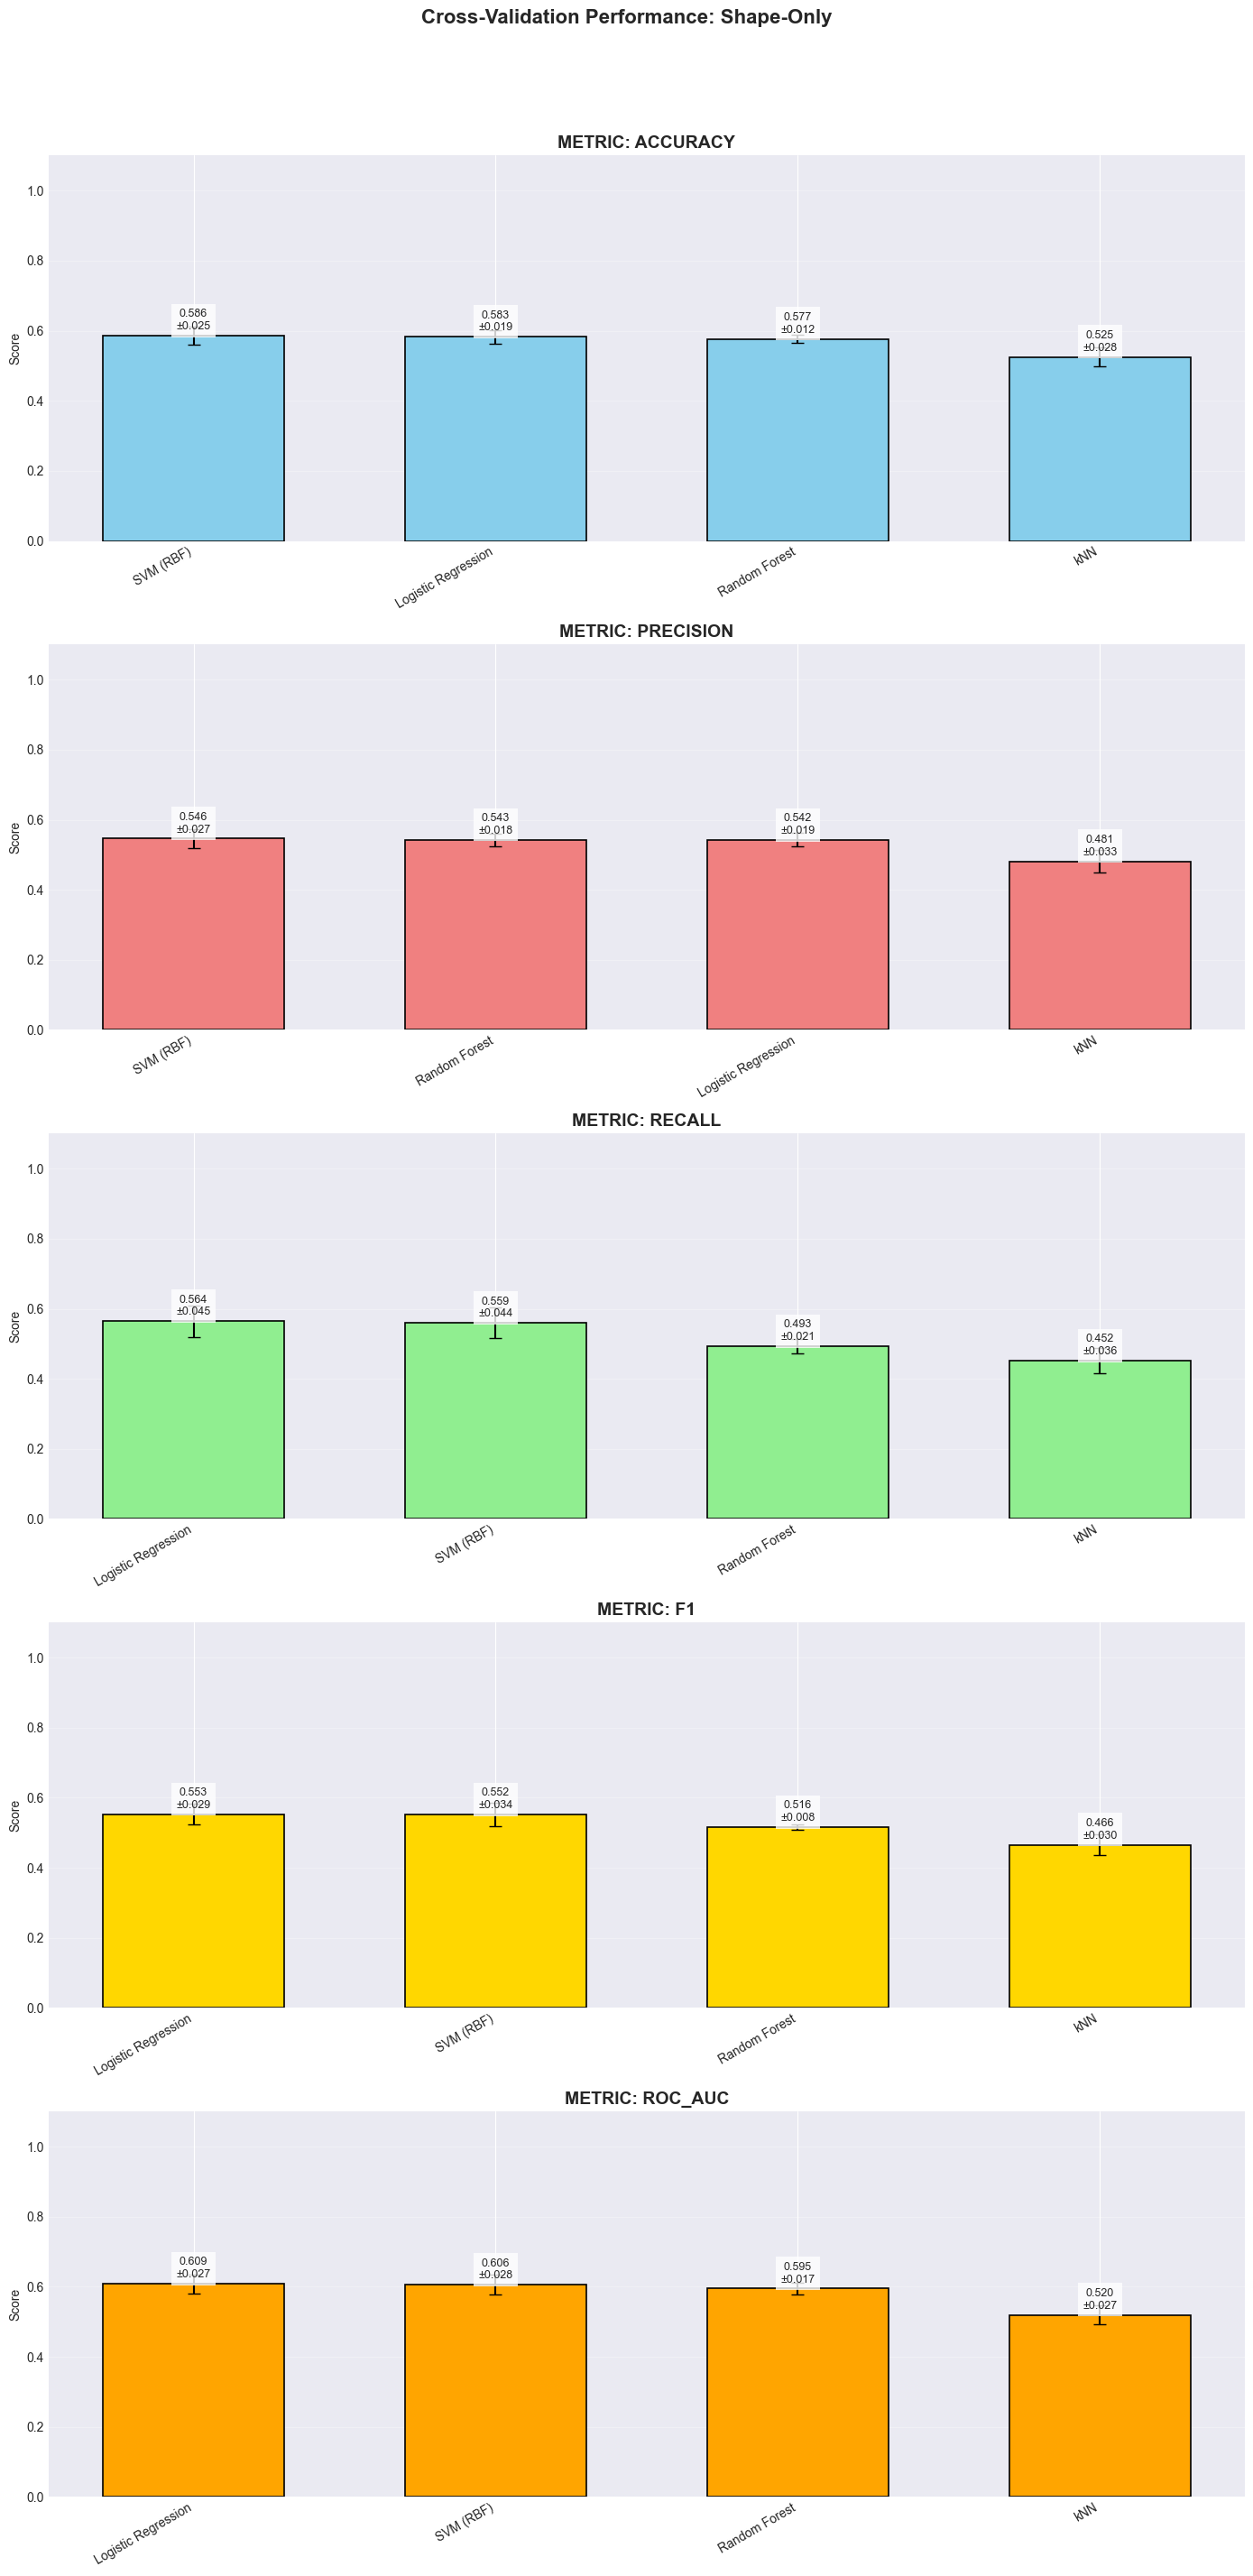


--- Generating CV Comparison Plots for: BI-RADS-Score-Only ---


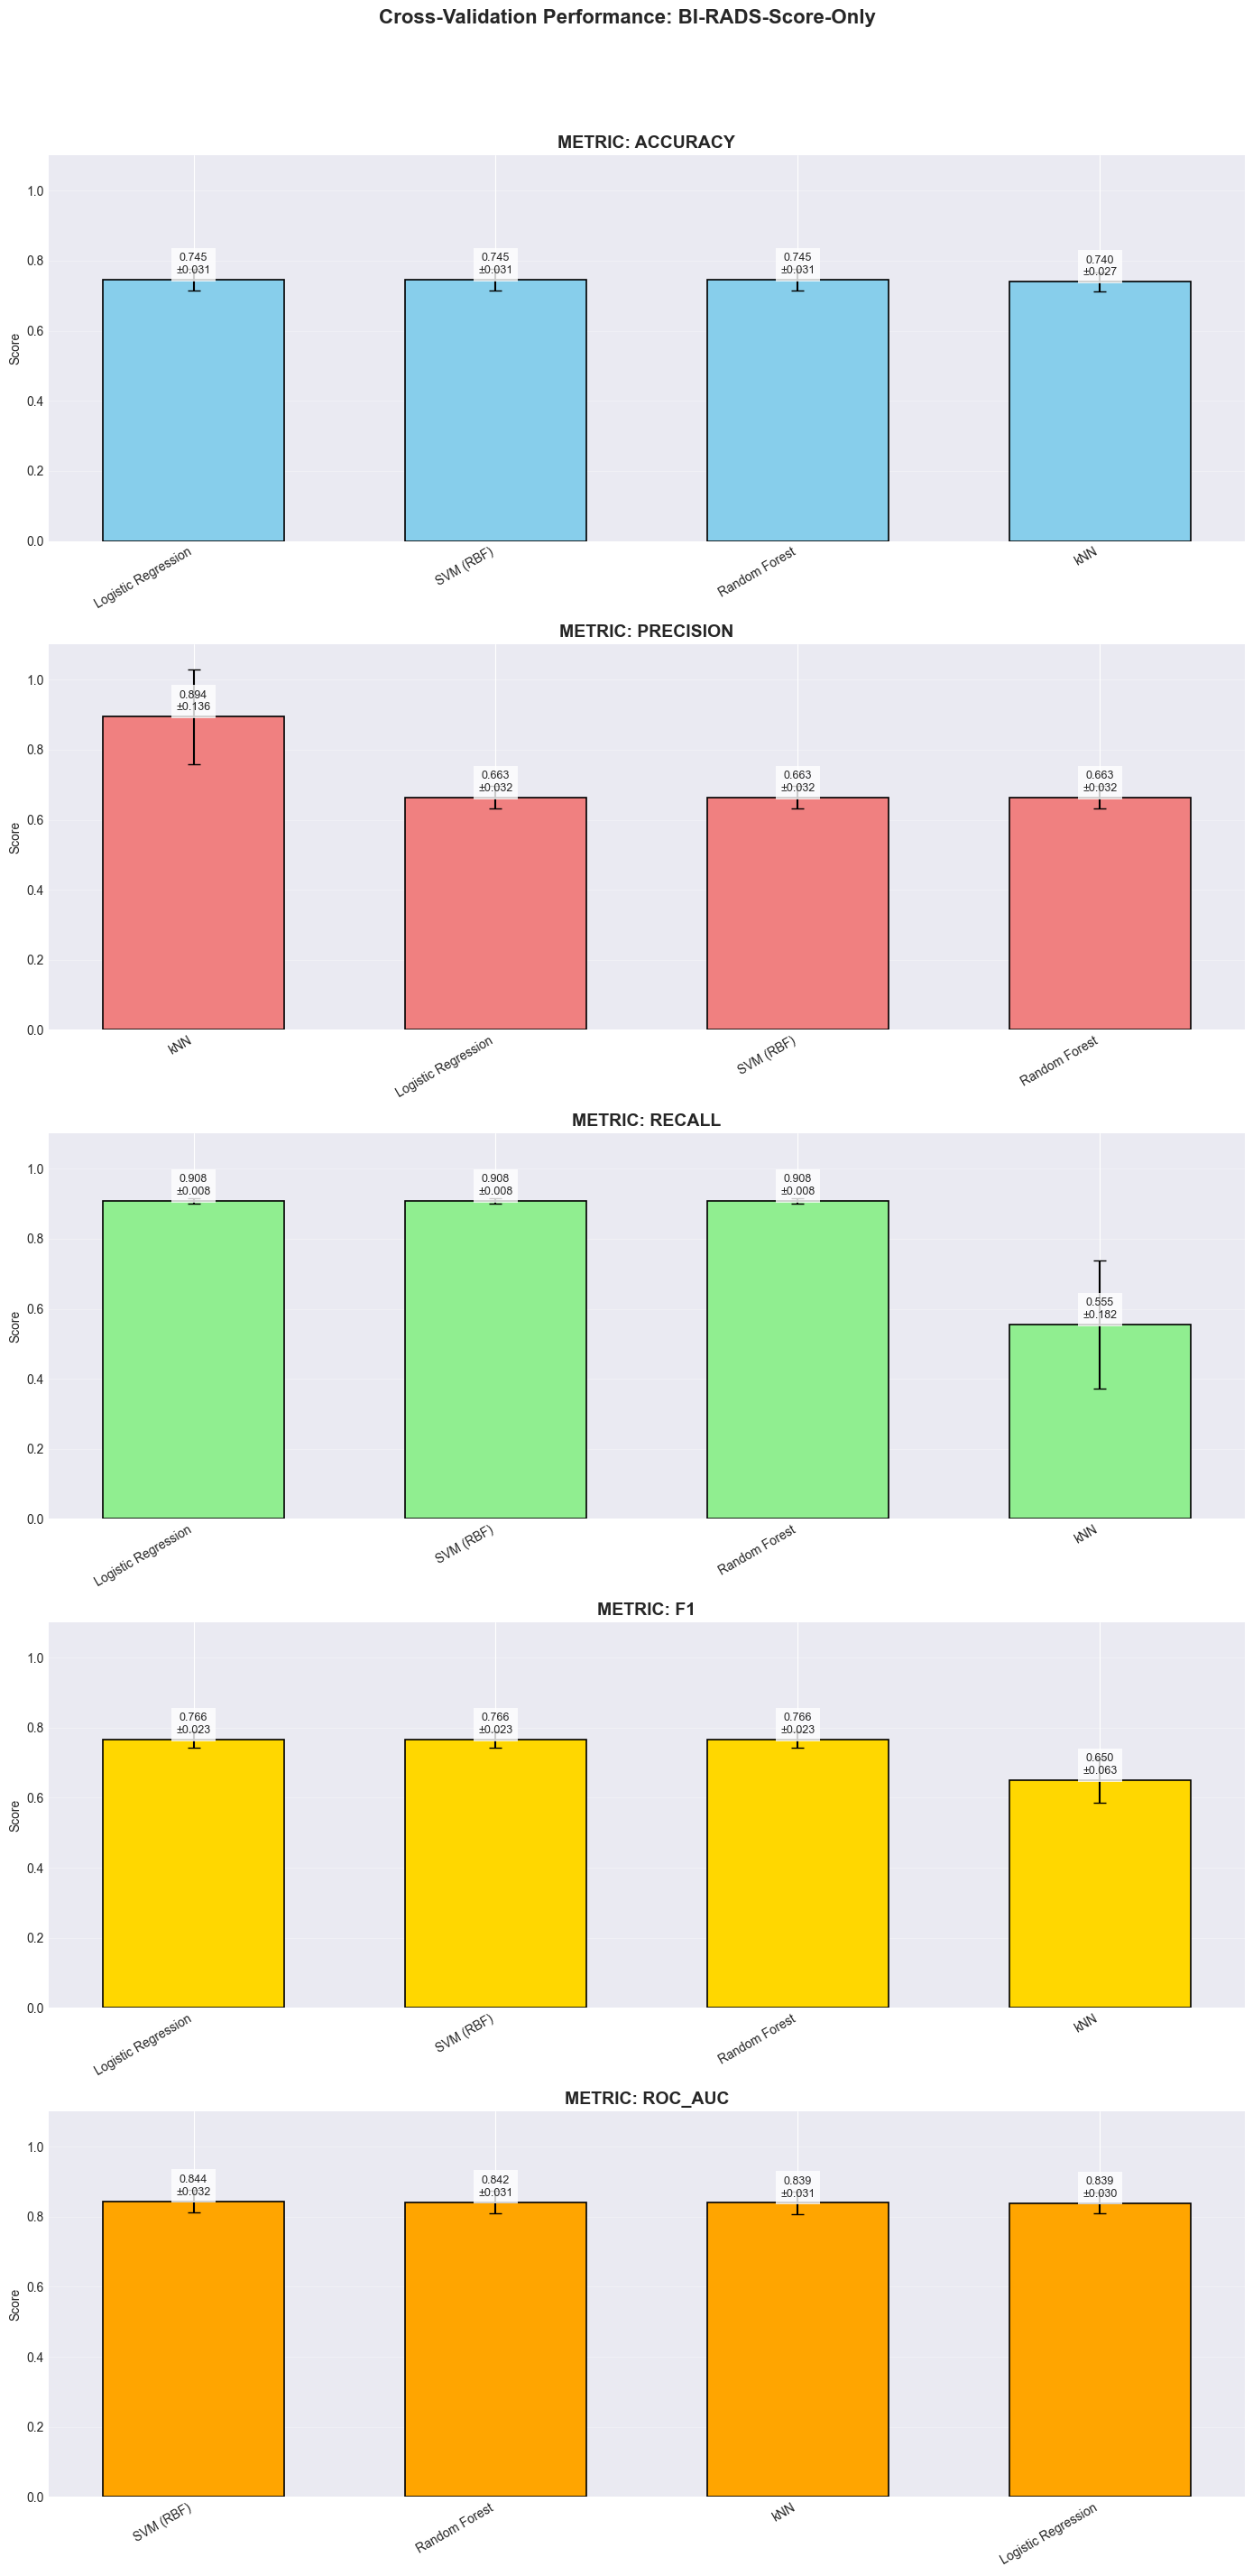


--- Generating CV Comparison Plots for: Hybrid (Shape + BI-RADS Score) ---


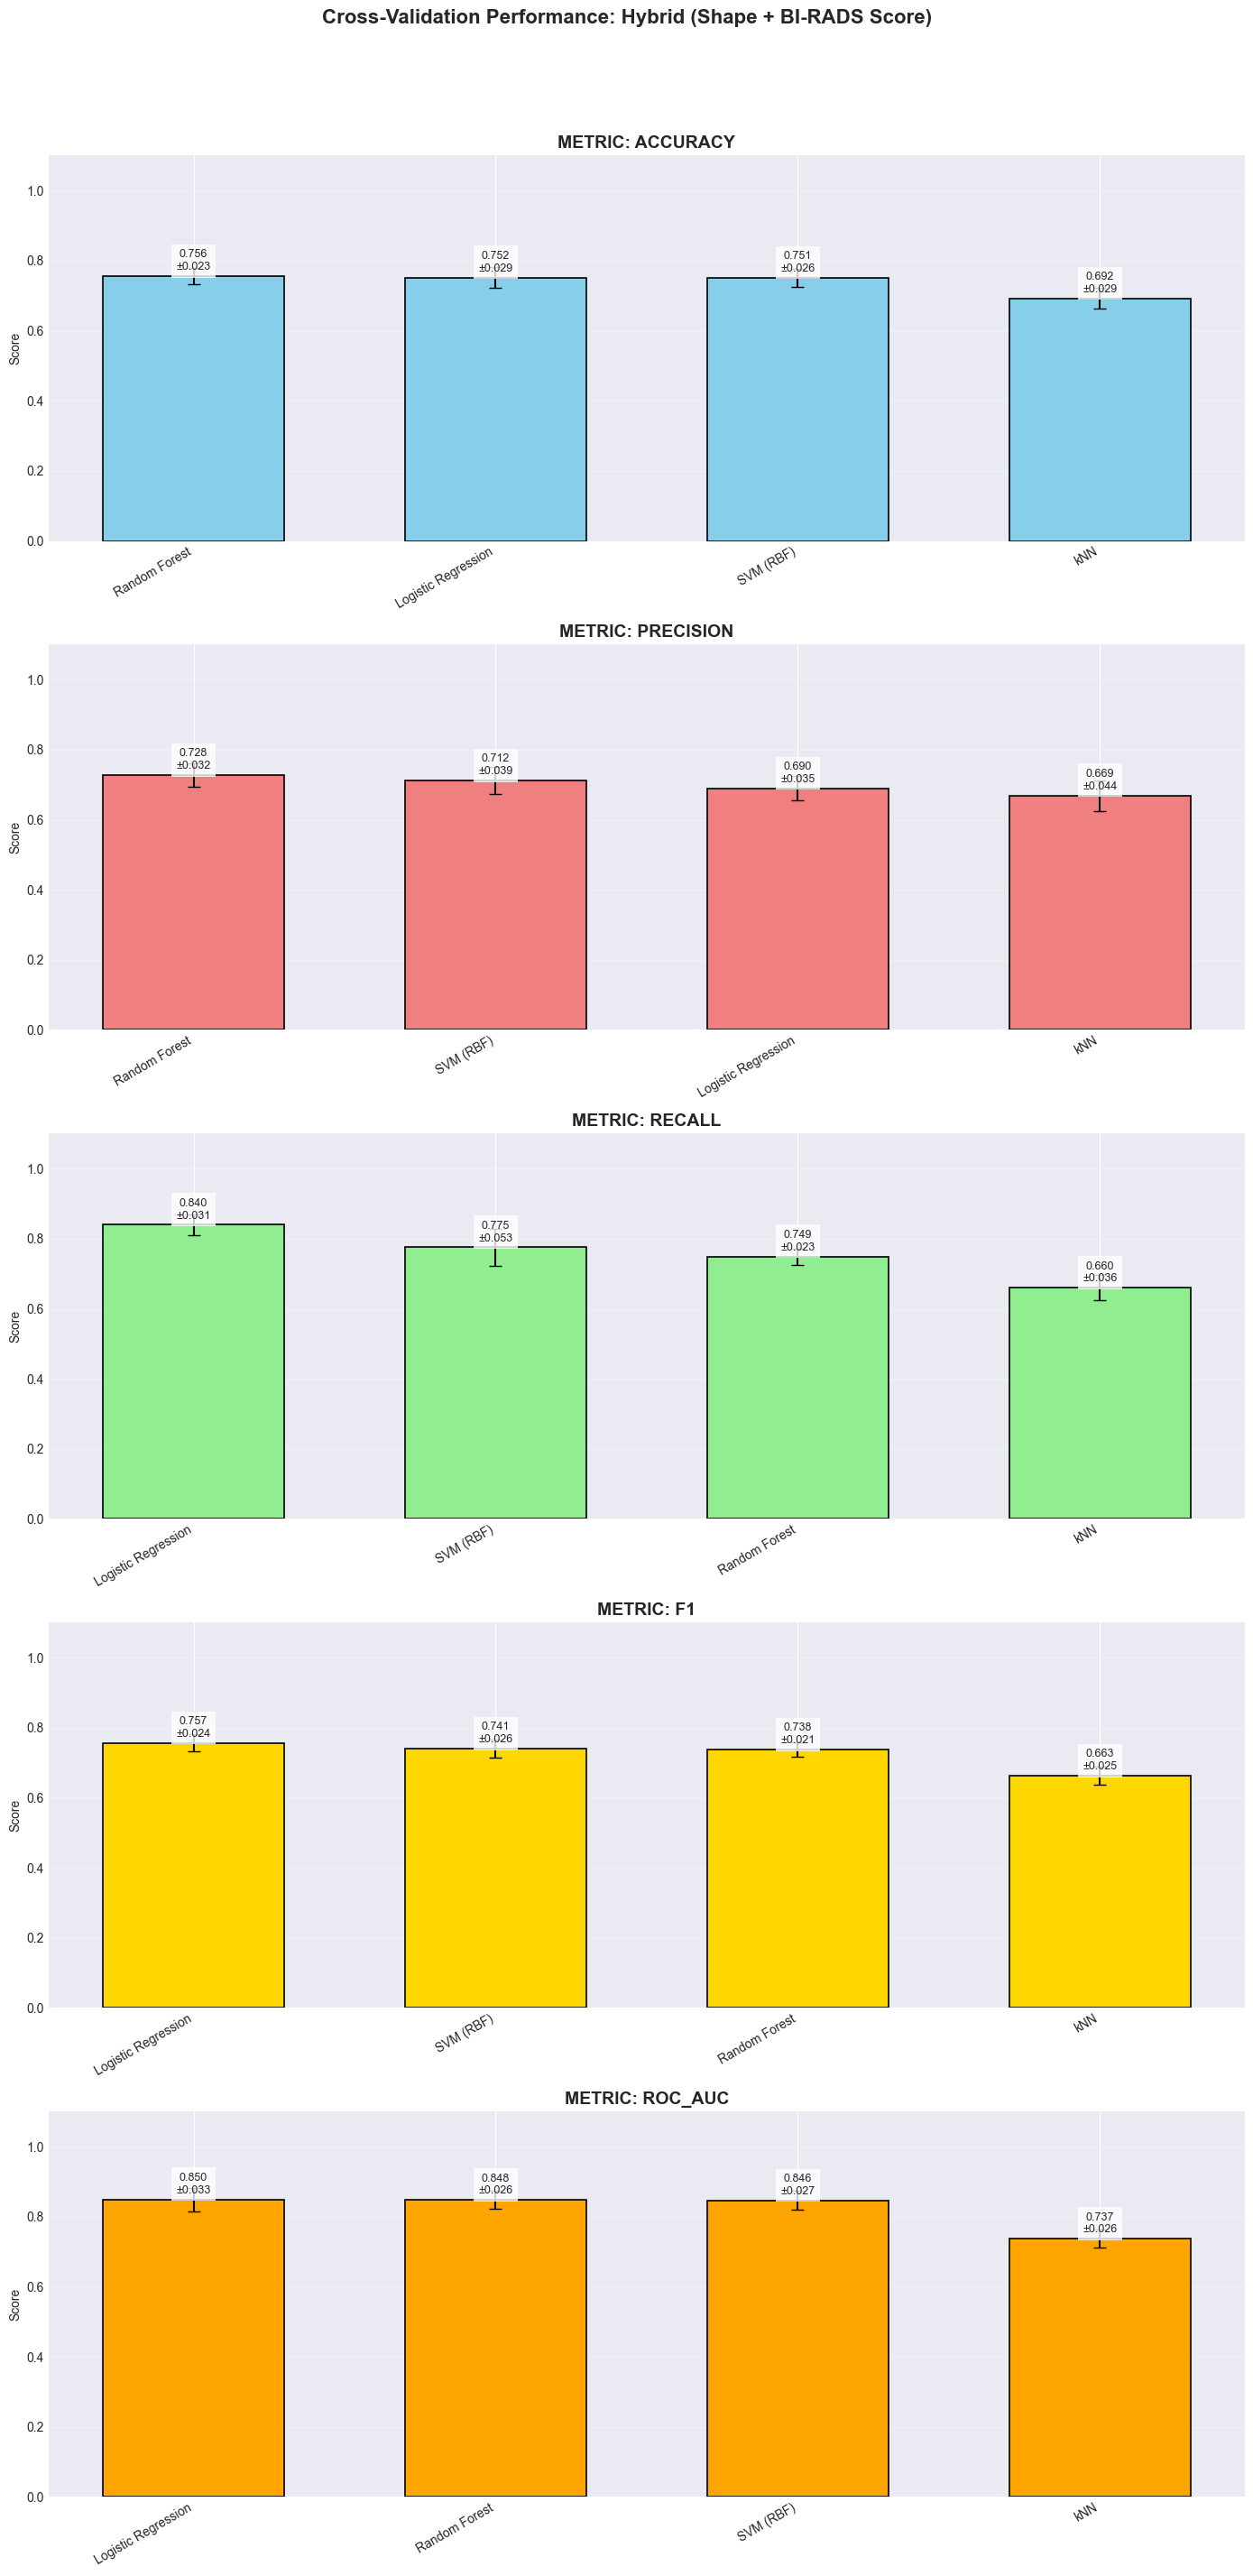

In [23]:
# CV Comparison Plots
if cv_results_data:
    COMPARISON_PLOT_PATH = "../output/cv_performance_comparison.png"
    model_eval.plot_cv_comparison(cv_results_data, scoring, COMPARISON_PLOT_PATH)

# Convert CV results to DataFrame for easier access
summary_df = pd.DataFrame(cv_results_data)

## Detailed Evaluation of the Best Models


------------------------------------------------------------
DETAILED EVALUATION: Shape-Only
------------------------------------------------------------
Best Model found via CV: Logistic Regression (roc_auc=0.6086)
Using TUNED hyperparameters.


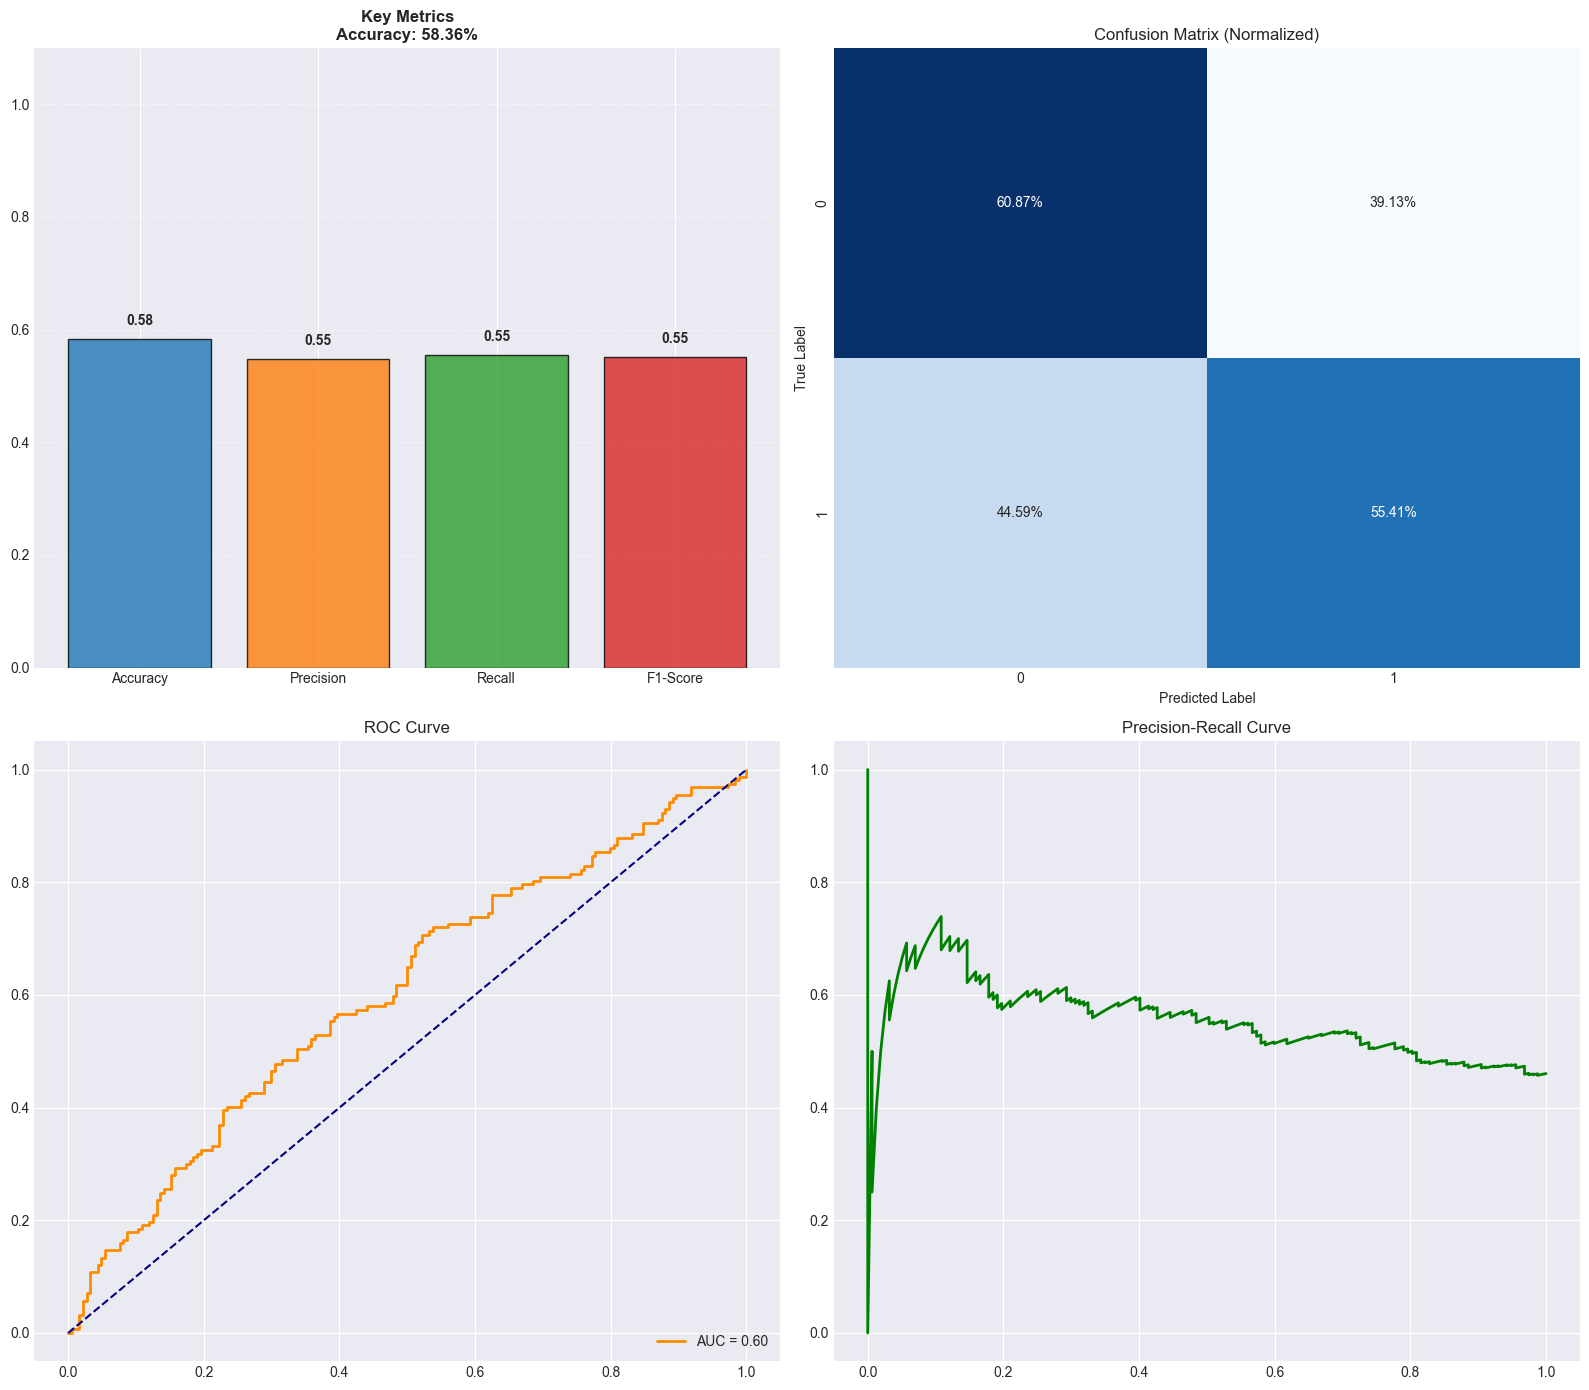

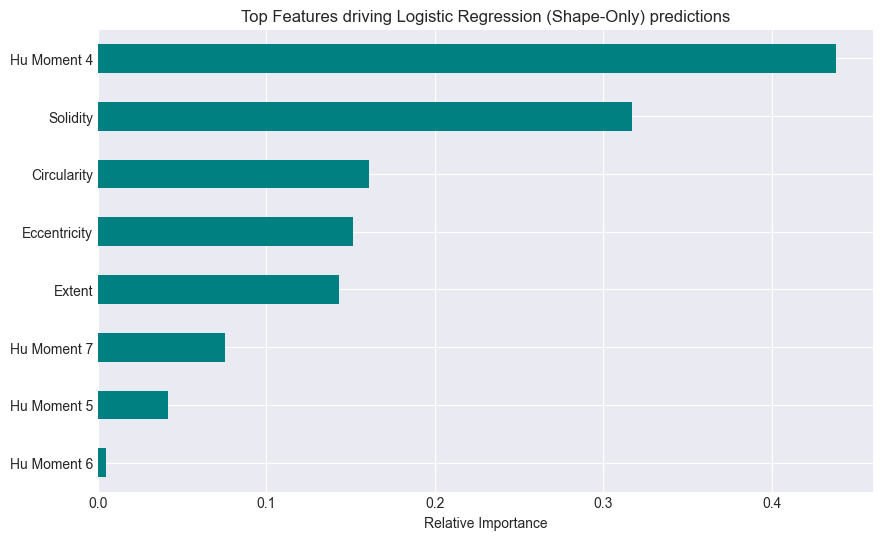

False Negatives: 70 | False Positives: 72

------------------------------------------------------------
DETAILED EVALUATION: BI-RADS-Score-Only
------------------------------------------------------------
Best Model found via CV: SVM (RBF) (roc_auc=0.8443)
Using TUNED hyperparameters.


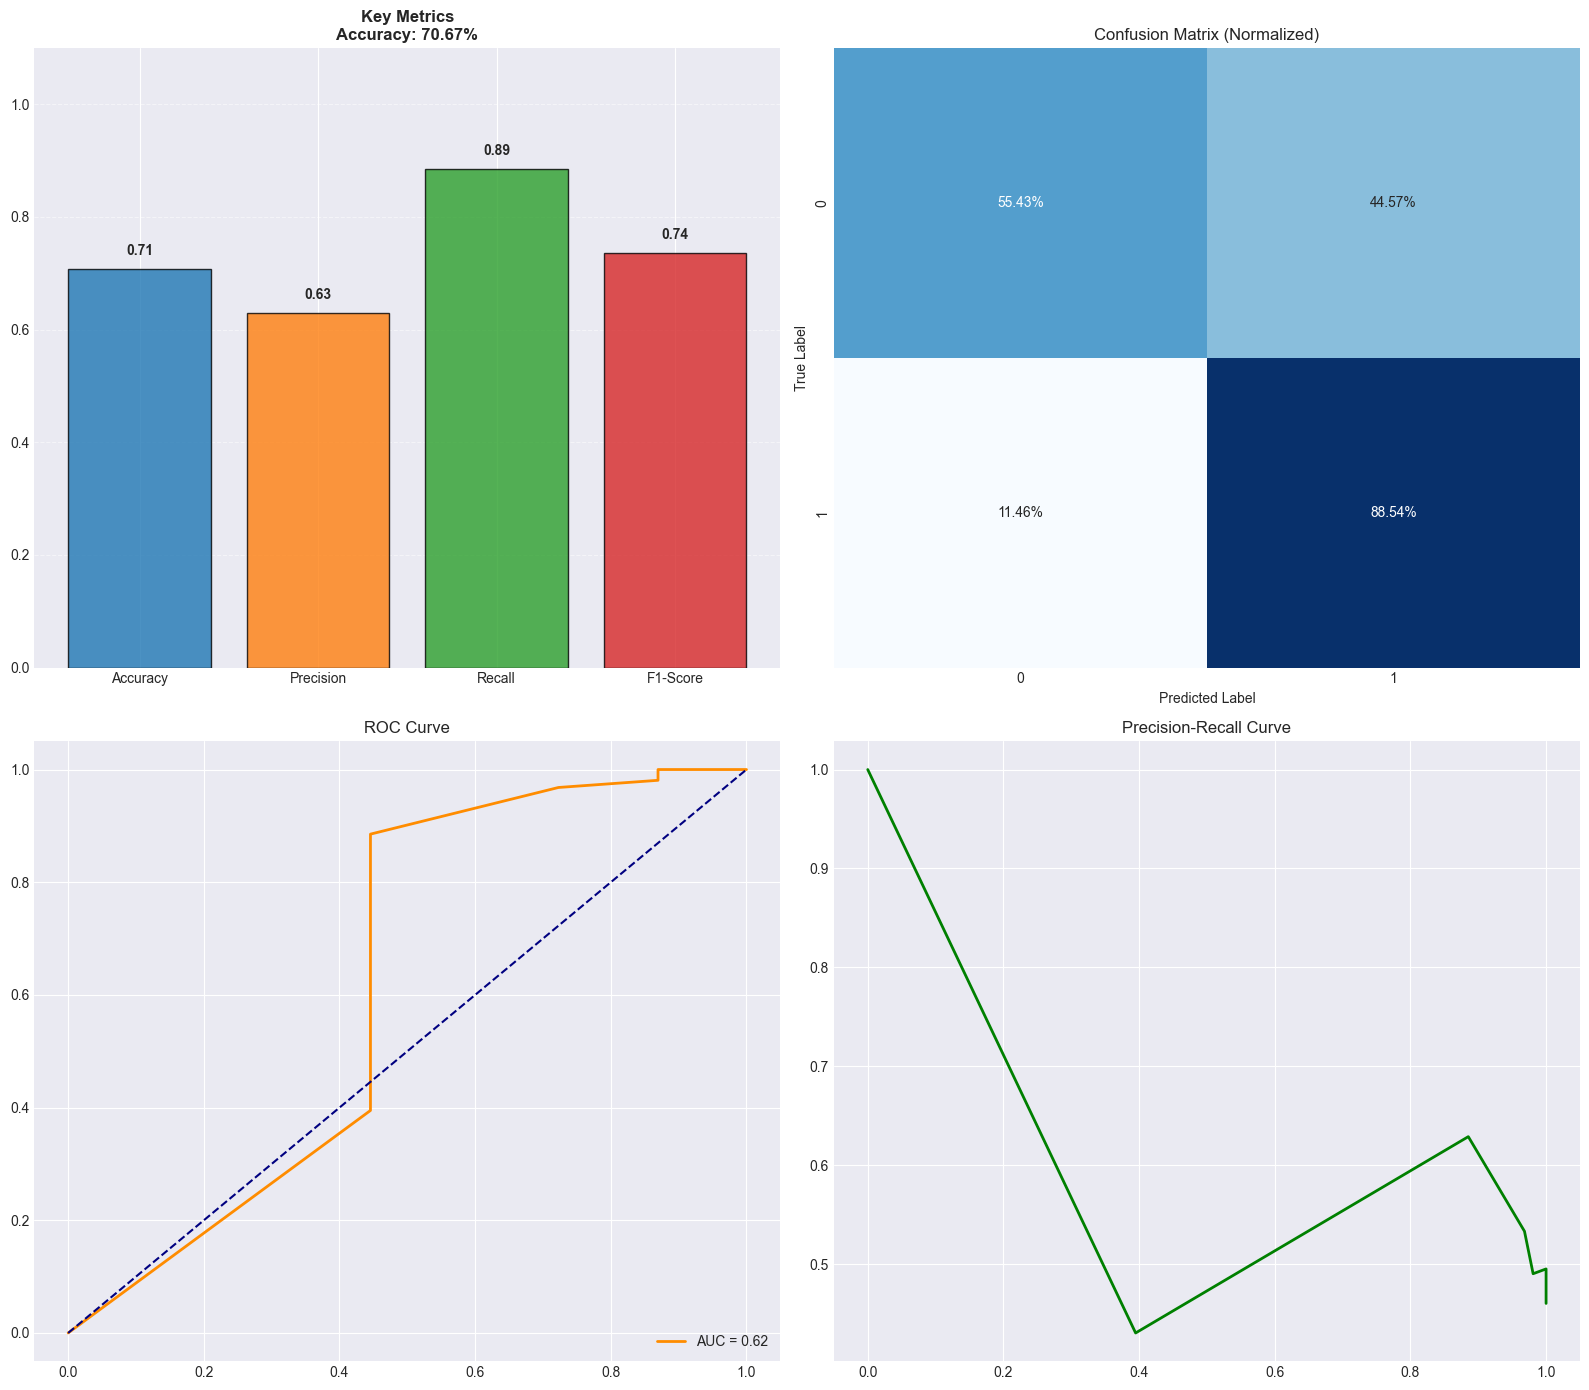


[INFO] Feature importance plot skipped for 'SVM (RBF) (BI-RADS-Score-Only)' (Not supported by this algorithm).
False Negatives: 18 | False Positives: 82

------------------------------------------------------------
DETAILED EVALUATION: Hybrid (Shape + BI-RADS Score)
------------------------------------------------------------
Best Model found via CV: Logistic Regression (roc_auc=0.8495)
Using TUNED hyperparameters.


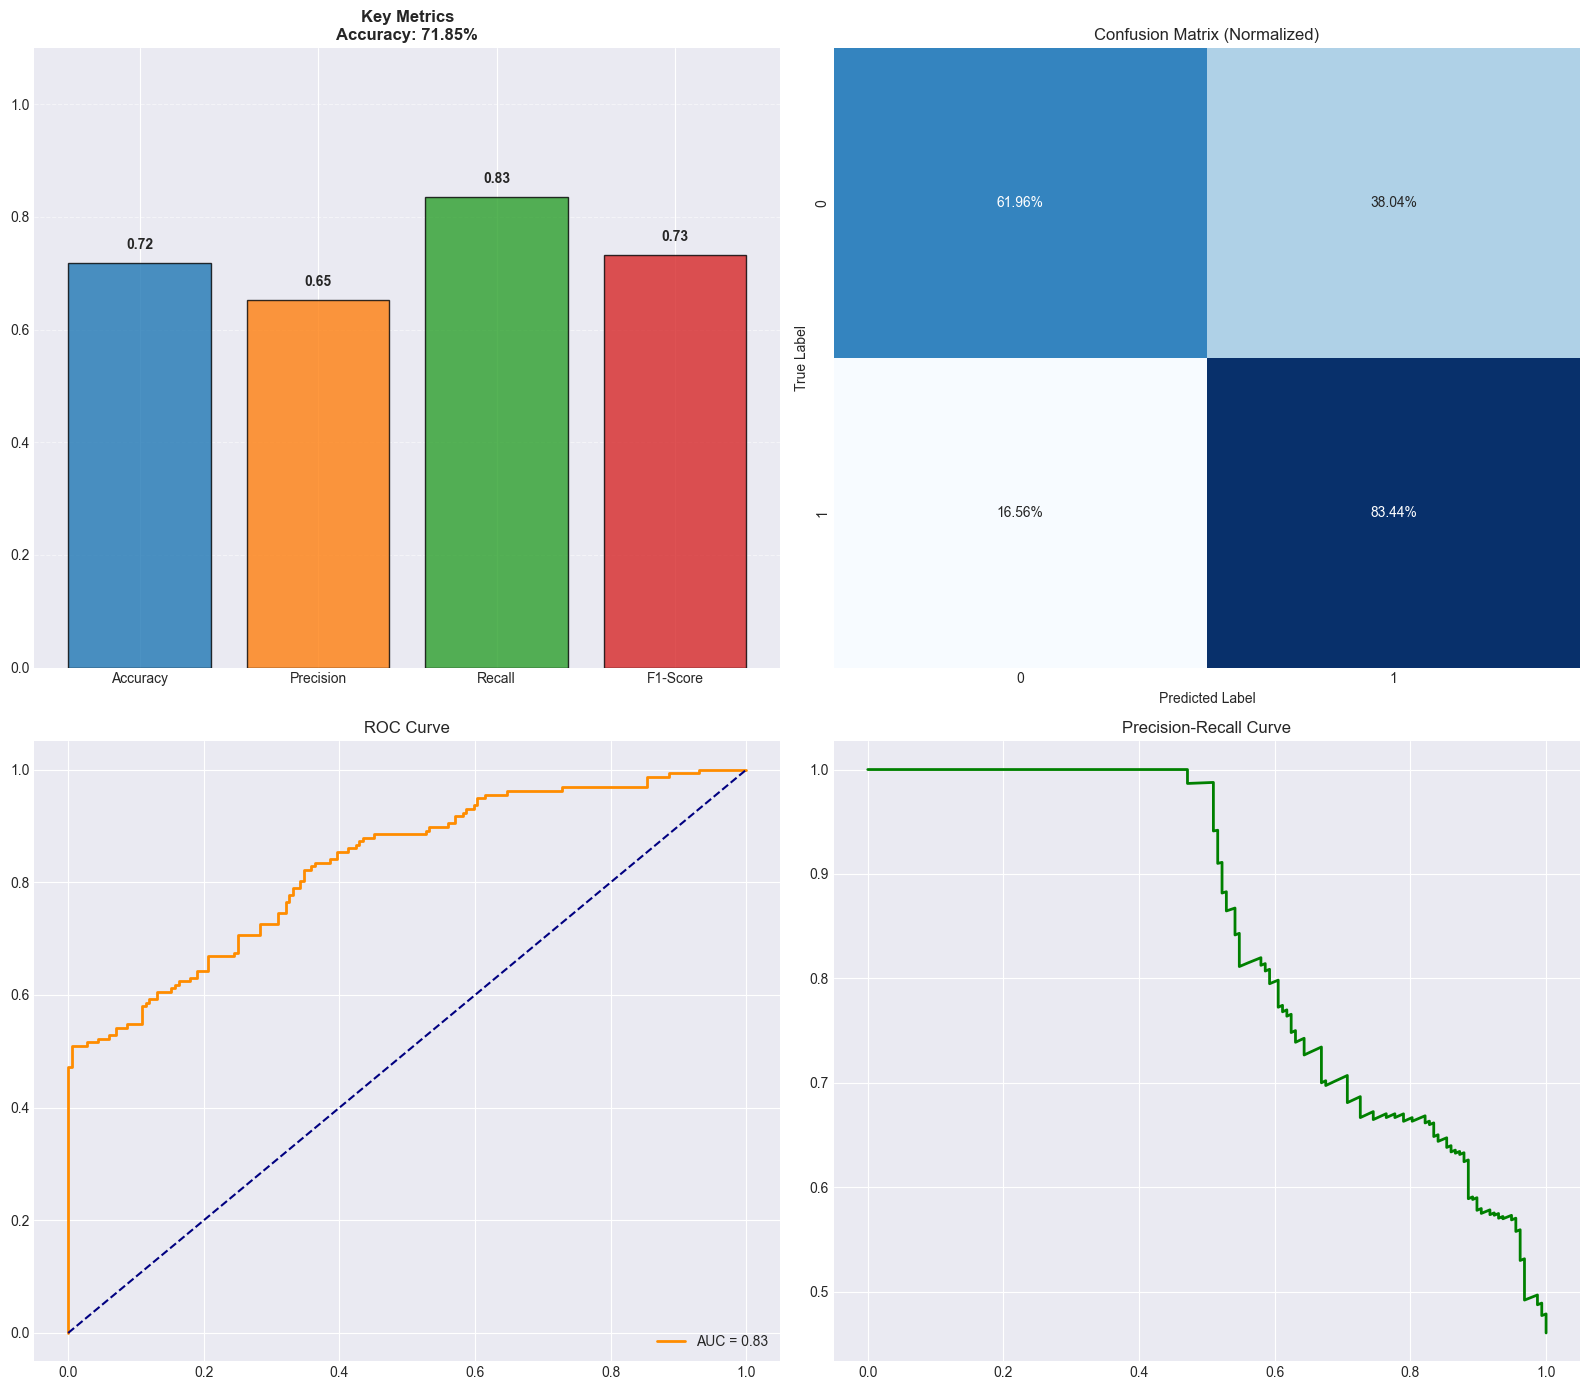

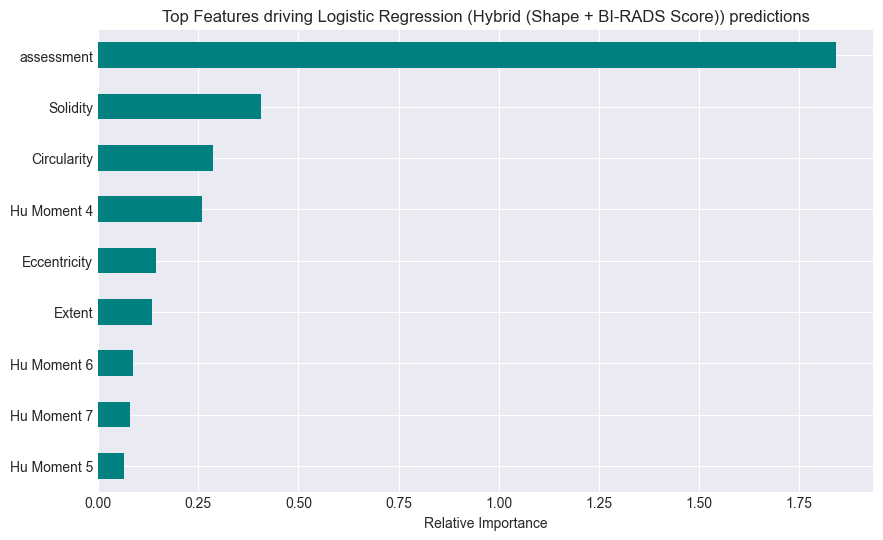

False Negatives: 26 | False Positives: 70


In [24]:
for vector_info in vectors:
    vec_name = vector_info['name']

    # Check if results exist for this vector
    if summary_df.empty or vec_name not in summary_df["Vector name: "].values:
        print(f"Skipping {vec_name} - No CV results found.")
        continue

    print(f"\n{'-' * 60}")
    print(f"DETAILED EVALUATION: {vec_name}")
    print(f"{'-' * 60}")

    # Filter results for current vector
    vec_results = summary_df[summary_df["Vector name: "] == vec_name]

    # Sort by ROC AUC descending to find the best model
    # Fallback to accuracy if roc_auc is missing for some reason
    target_metric = 'roc_auc' if 'roc_auc' in vec_results['Metric'].values else 'accuracy'

    # Get the top row
    best_row = vec_results[vec_results['Metric'] == target_metric].sort_values('Mean', ascending=False).iloc[0]

    best_model_name = best_row['Model']
    best_score = best_row['Mean']

    print(f"Best Model found via CV: {best_model_name} ({target_metric}={best_score:.4f})")

    # Select the best model instance
    best_model_instance = None

    # The winner is a Tuned Model (exists in tuning dictionary)
    if vec_name in best_models_per_vector and best_model_name in best_models_per_vector[vec_name]:
        best_model_instance = best_models_per_vector[vec_name][best_model_name]
        print(f"Using TUNED hyperparameters.")

    # The winner is a Default Model (or tuning was skipped)
    else:
        best_model_instance = models_list[best_model_name]
        print(f"Using DEFAULT hyperparameters.")

    # Retrain on full training set (just to be safe)
    best_model_instance.fit(vector_info['X_train'], vector_info['y_train'])

    # Run evaluation function
    fn_cases, fp_cases = model_eval.run_detailed_evaluation(
        model=best_model_instance,
        X_test=vector_info['X_test'],
        y_test=vector_info['y_test'],
        feature_names=vector_info['X_train'].columns,
        model_name=f"{best_model_name} ({vec_name})"
    )

    print(f"False Negatives: {len(fn_cases)} | False Positives: {len(fp_cases)}")

## Conclusion